# Superstore Sales Analysis
This notebook analyzes company sales and profitability using the Sample Superstore dataset.

## Goals
- Load and inspect the dataset
- Check missing values and duplicates
- Analyze sales, profit, categories, regions, and products
- Build visualizations and summarize business insights

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
df = pd.read_csv('superstore_sales.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

## Data Cleaning
We check missing values and duplicates. Even if the dataset is already clean, this step must be documented.

In [ ]:
missing_values = df.isna().sum()
duplicates_count = df.duplicated().sum()

print('Missing values by column:')
print(missing_values)
print('\nDuplicate rows:', duplicates_count)

df = df.drop_duplicates().copy()

Missing values by column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicate rows: 0


## Basic Overview

In [ ]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
categories = df['Category'].unique()

print('Total sales:', total_sales)
print('Total profit:', total_profit)
print('Categories:', categories)

Total sales: 2297200.8603000003
Total profit: 286397.0217
Categories: ['Furniture' 'Office Supplies' 'Technology']


## 1. Profit by Category

In [ ]:
profit_by_category = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
profit_by_category

,Profit
Category,
Technology,145454.9481
Office Supplies,122490.8008
Furniture,18451.2728


## 2. Sales by Region

In [ ]:
sales_by_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
sales_by_region

,Sales
Region,
West,725457.8245
East,678781.2400
Central,501239.8908
South,391721.9050


## 3. Loss-Making Rows

In [ ]:
loss_rows = df[df['Profit'] < 0]
loss_rows[['Product Name', 'Category', 'Region', 'Sales', 'Profit']].head(10)

,Product Name,Category,Region,Sales,Profit
3,Bretford CR4500 Series Slim Rectangular Table,Furniture,South,957.5775,-383.0310
14,Holmes Replacement Filter for HEPA Air Cleaner...,Office Supplies,Central,68.8100,-123.8580
15,Storex DuraTech Recycled Plastic Frosted Binders,Office Supplies,Central,2.5440,-3.8160
23,"Global Deluxe Stacking Chair, Gray",Furniture,East,71.3720,-1.0196
27,"Riverside Palais Royal Lawyers Bookcase, Royal...",Furniture,East,3083.4300,-1665.0522
28,Avery Recycled Flexi-View Covers for Binding S...,Office Supplies,East,9.6180,-7.0532
32,"Acco Pressboard Covers with Storage Hooks, 14 ...",Office Supplies,East,6.8580,-5.7150
36,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",Furniture,Central,190.9200,-147.9630
38,"Atlantic Metals Mobile 3-Shelf Bookcases, Cust...",Furniture,Central,532.3992,-46.9764
39,"Global Fabric Manager's Chair, Dark Gray",Furniture,Central,212.0580,-15.1470


## 4. Top Products by Revenue

In [ ]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


## Visualizations

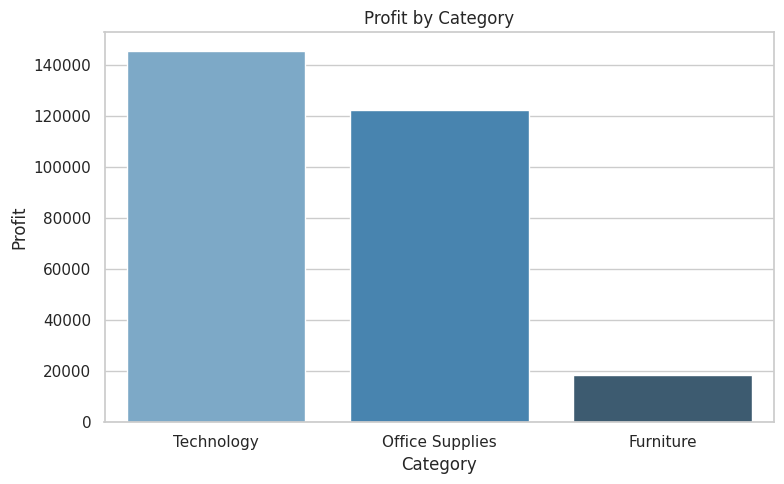

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x=profit_by_category.index, y=profit_by_category.values, hue=profit_by_category.index, palette='Blues_d', legend=False)
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

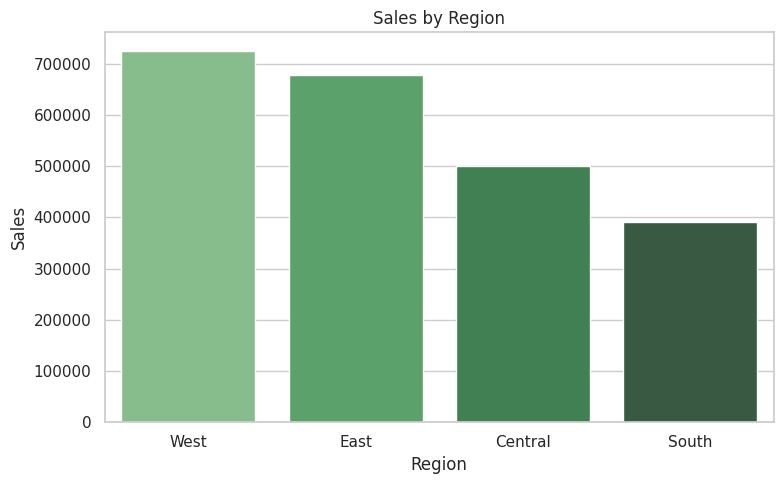

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x=sales_by_region.index, y=sales_by_region.values, hue=sales_by_region.index, palette='Greens_d', legend=False)
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

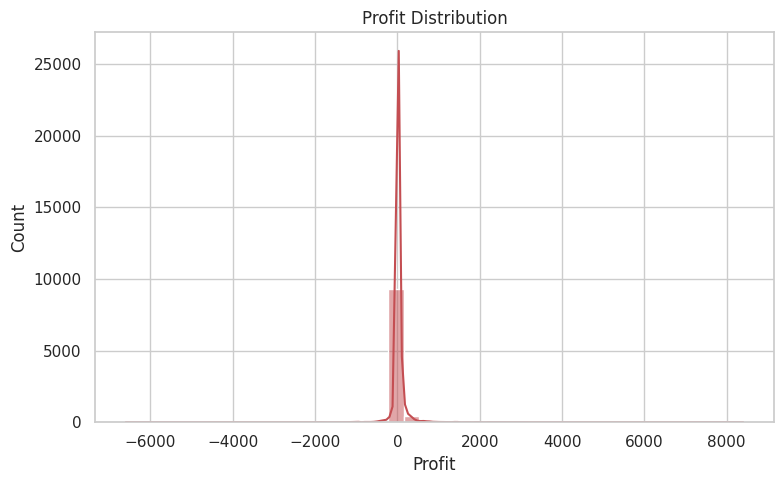

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Profit'], bins=40, kde=True, color='#C44E52')
plt.title('Profit Distribution')
plt.xlabel('Profit')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

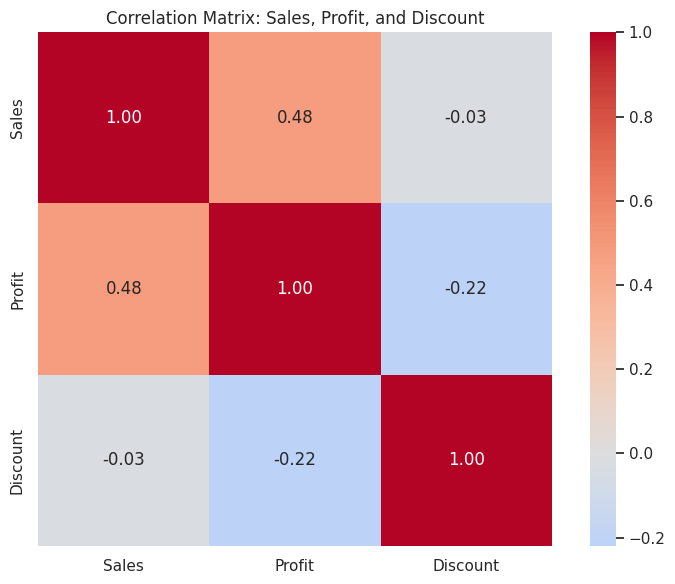

In [ ]:
plt.figure(figsize=(8, 6))
corr_matrix = df[['Sales', 'Profit', 'Discount']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix: Sales, Profit, and Discount')
plt.tight_layout()
plt.show()

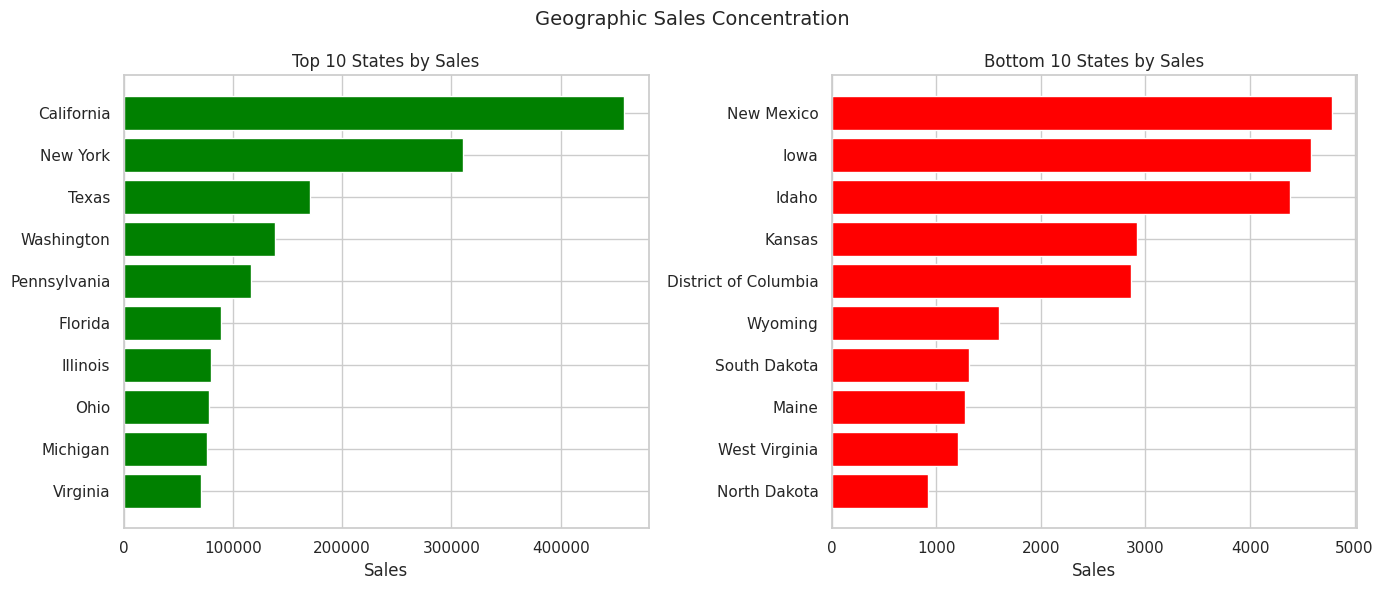

Top 10 states: Texas, New York, California = $938,752 (40.9%)
Outsiders: North Dakota, West Virginia, Maine = $3,400 (0.15%)


In [ ]:
state_sales = df.groupby('State')['Sales'].sum().sort_values()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
# Top 10 states
top_10 = state_sales.tail(10)
ax1.barh(top_10.index, top_10.values, color='green')
ax1.set_title('Top 10 States by Sales')
ax1.set_xlabel('Sales')
# Bottom 10 states
bottom_10 = state_sales.head(10)
ax2.barh(bottom_10.index, bottom_10.values, color='red')
ax2.set_title('Bottom 10 States by Sales')
ax2.set_xlabel('Sales')
plt.suptitle('Geographic Sales Concentration', fontsize=14)
plt.tight_layout()
plt.show()
state_sales = df.groupby('State')['Sales'].sum().sort_values()
top3 = state_sales.tail(3)
bottom3 = state_sales.head(3)
total_sales = df['Sales'].sum()
print(f"Top 10 states: {', '.join(top3.index)} = ${top3.sum():,.0f} ({top3.sum()/total_sales*100:.1f}%)")
print(f"Outsiders: {', '.join(bottom3.index)} = ${bottom3.sum():,.0f} ({bottom3.sum()/total_sales*100:.2f}%)")

/tmp/ipykernel_1616/4112423371.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Weekday', y='Profit', order=weekday_order, palette='Set3')


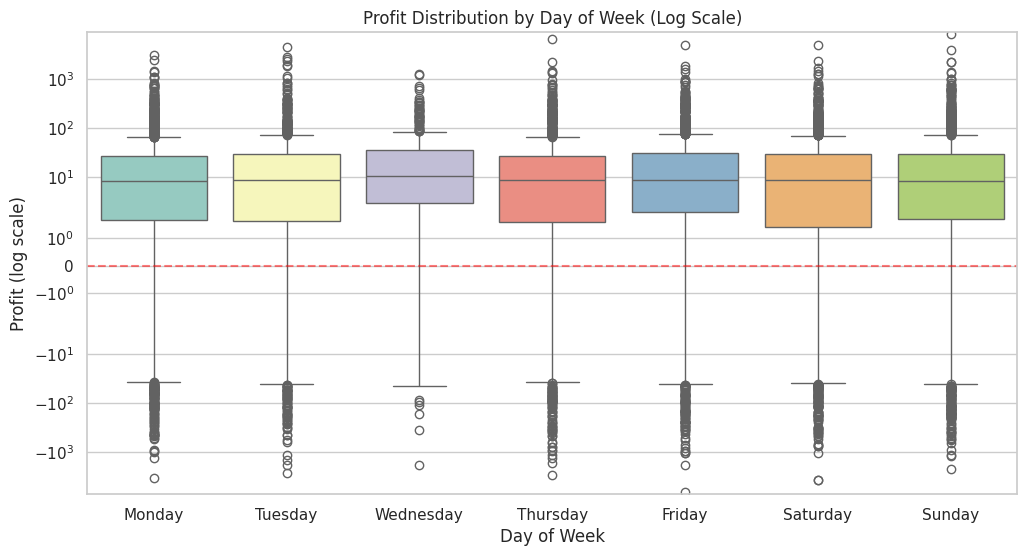

Median daily profit
Monday: $8.31
Tuesday: $8.72
Wednesday: $10.46
Thursday: $8.67
Friday: $8.80
Saturday: $8.57
Sunday: $8.36


In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Weekday'] = df['Order Date'].dt.day_name()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Weekday', y='Profit', order=weekday_order, palette='Set3')
plt.yscale('symlog')
plt.title('Profit Distribution by Day of Week (Log Scale)')
plt.xlabel('Day of Week')
plt.ylabel('Profit (log scale)')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.show()
df['Weekday'] = pd.to_datetime(df['Order Date']).dt.day_name()
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
profit_by_day = df.groupby('Weekday')['Profit'].median().reindex(days)
print(f"Median daily profit")
for day in days:
    print(f"{day}: ${profit_by_day[day]:.2f}")

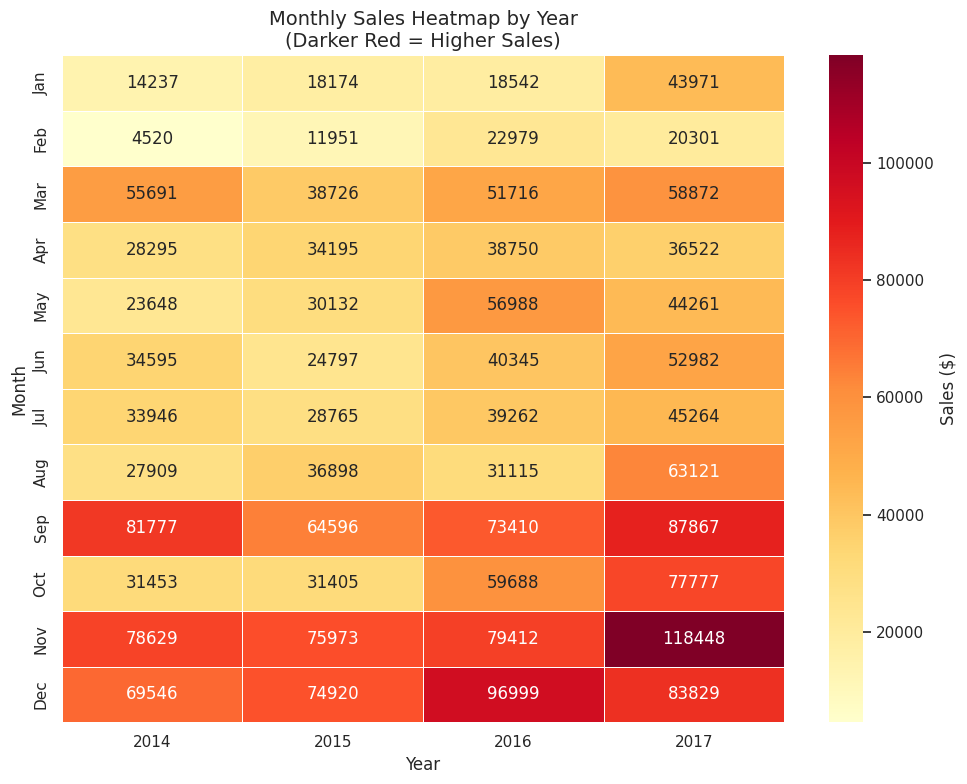

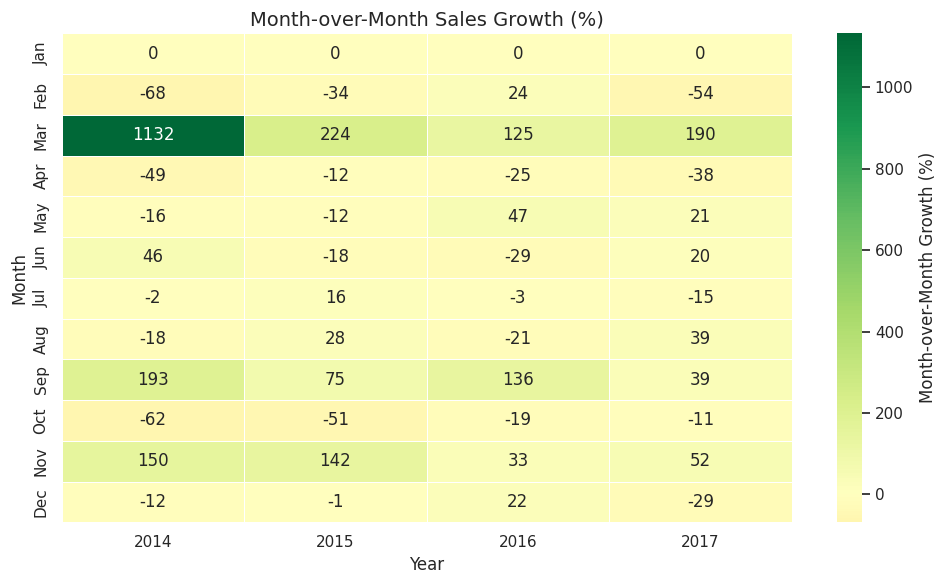


Seasonality correlation between 2016 and 2017: -0.14


In [ ]:
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year

# Create pivot table for heatmap
monthly_sales = df.pivot_table(values='Sales', index='Month', columns='Year', aggfunc='sum')

# Month names for better labels
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_sales.index = month_names

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(monthly_sales, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Sales ($)'})
plt.title('Monthly Sales Heatmap by Year\n(Darker Red = Higher Sales)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Month')
plt.tight_layout()
plt.show()
monthly_sales_pct = monthly_sales.pct_change().fillna(0) * 100
plt.figure(figsize=(10, 6))
sns.heatmap(monthly_sales_pct, annot=True, fmt='.0f', cmap='RdYlGn', center=0,
            linewidths=0.5, cbar_kws={'label': 'Month-over-Month Growth (%)'})
plt.title('Month-over-Month Sales Growth (%)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Month')
plt.tight_layout()
plt.show()
yearly_pattern = df.pivot_table(values='Sales', index='Month', columns='Year', aggfunc='mean')
yearly_pattern.index = month_names
if 2016 in yearly_pattern.columns and 2017 in yearly_pattern.columns:
    corr = yearly_pattern[2016].corr(yearly_pattern[2017])
    print(f"\nSeasonality correlation between 2016 and 2017: {corr:.2f}")

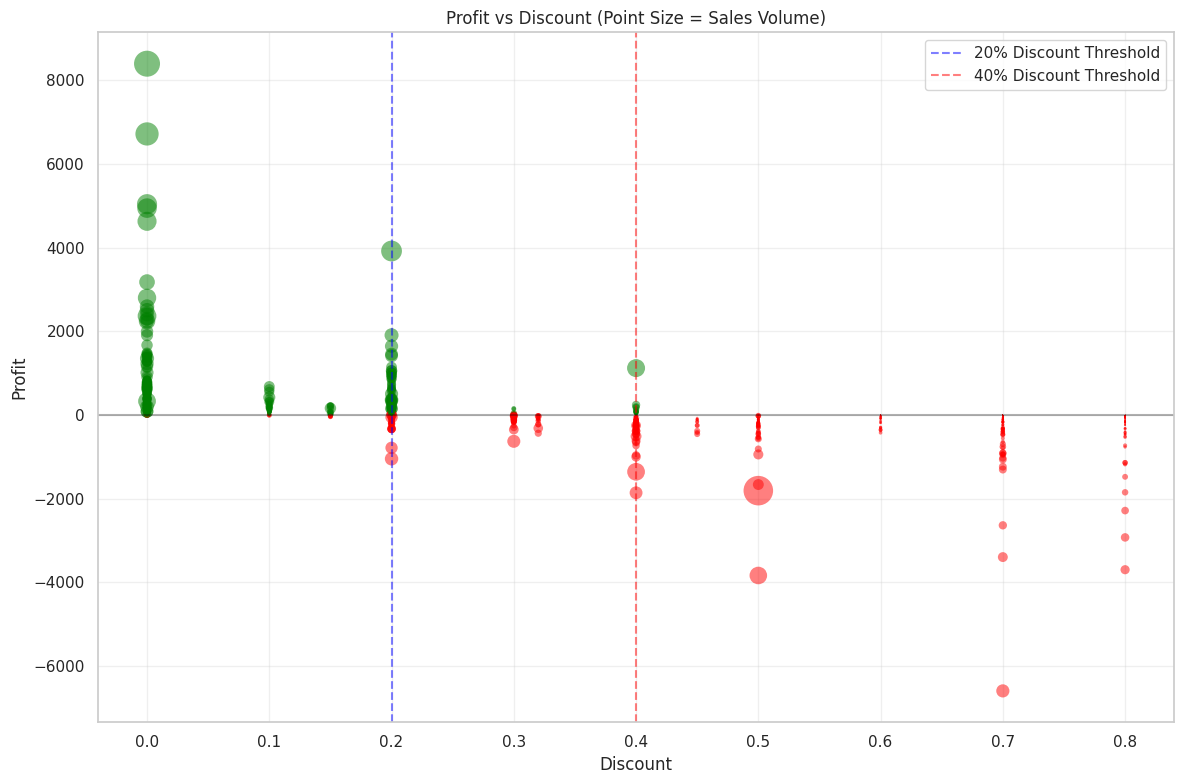

Discount  >40%: 933 out of 933 are unprofitable (100%)


In [ ]:
plt.figure(figsize=(12, 8))
colors = df['Profit'].apply(lambda x: 'green' if x > 0 else 'red')
scatter = plt.scatter(df['Discount'], df['Profit'],
                      s=df['Sales']/50,
                      c=colors, alpha=0.5, edgecolors='none')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Profit vs Discount (Point Size = Sales Volume)')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.axvline(x=0.2, color='blue', linestyle='--', alpha=0.5, label='20% Discount Threshold')
plt.axvline(x=0.4, color='red', linestyle='--', alpha=0.5, label='40% Discount Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
high_disc = df[df['Discount'] > 0.4]
loss_high = (high_disc['Profit'] < 0).sum()
print(f"Discount  >40%: {loss_high} out of {len(high_disc)} are unprofitable ({loss_high/len(high_disc)*100:.0f}%)")

## Conclusions
- Technology is the most profitable category with profit of 145454.95.
- The West region leads in sales with revenue of 725457.82.
- There are 1871 unprofitable order lines where Profit is below zero.
- The top product by revenue is 'Canon imageCLASS 2200 Advanced Copier' with sales of 61599.82.
- The dataset is already clean from missing values and exact duplicate rows.
- Discount has a weak negative correlation with profit (-0.22) and almost no correlation with sales (-0.03). This indicates that discounting has a limited negative impact on profitability and does not drive sales growth.
- Texas, New York, and California together account for 40.9% of total sales (938.752), while North Dakota, West Virginia, and Maine contribute only 0.15% (3.400). This extreme geographic concentration suggests significant untapped market potential in underperforming states.
- Day of week has minimal impact on profitability. All days show similar median profit (8-10) and wide distributions with numerous outliers. This suggests that operational factors (discounts, order size, product mix) drive profitability far more than timing.
- Seasonal patterns show strong but inconsistent peaks. November averages 88,116, with growth from October ranging from +33% to +150% across years. The highest November peak occurred in 2017 (118,448). However, the correlation between 2016 and 2017 seasonality is weak (-0.14), indicating limited year-to-year predictability.
- Discounts exceeding 40% result in losses 100% of the time (933 out of 933 transactions). Profitable transactions cluster in the 0-20% discount range. Large-volume transactions with discounts above 30% consistently generate substantial losses. These findings strongly suggest implementing a strict discount policy with a maximum threshold of 20-25%.